# VGG-11 图像分类案例：CIFAR-10 数据集

## 1. 知识点简述

**VGG 网络**是由牛津大学视觉几何组（Visual Geometry Group）在 2014 年提出的经典深度卷积神经网络。其核心思想是使用**更小的卷积核（3x3）**和**更深的网络结构**来提升模型性能。

**VGG-11** 是该系列中结构最简单的一个版本，由 8 个卷积层和 3 个全连接层组成。

### 核心特性：
- **大量使用 3x3 卷积核**：两个 3x3 卷积层的感受野对应一个 5x5 卷积层，但参数更少且包含更多非线性激活。
- **池化层降采样**：使用 2x2 的最大池化层，步长为 2，每次池化后图像尺寸减半，通道数通常加倍。
- **全连接层**：末端包含三个全连接层进行分类。

## 2. 设计程序的意义

1.  **教学示范**：VGG 结构极其规整，是学习深度卷积神经网络（CNN）架构设计的最佳入门教材。
2.  **理解深度对特征提取的影响**：通过实验观察随着层数增加，网络如何从基础边缘特征进化到高级语义特征。
3.  **掌握 PyTorch 实战流程**：从数据预处理、模型构建、训练循环到测试评估，完整走通深度学习项目闭环。
4.  **迁移学习基础**：掌握 VGG 后，开发者可以更容易理解 ResNet、Inception 等更复杂的先进模型。


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd
import os
from PIL import Image
from tqdm import tqdm
from IPython.display import clear_output

# 设置随机种子以保证结果可重复
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的设备: {device}")


当前使用的设备: cuda


## 3. 数据预处理与加载

CIFAR-10 数据集包含 60,000 张 32x32 的彩色图像，分为 10 个类别。
在训练时，我们使用数据增强（随机裁剪、水平翻转）来提高模型的泛化能力。


In [19]:
# 类别定义 (对应 Kaggle CIFAR-10 数据集中的标签)
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
label_to_idx = {label: i for i, label in enumerate(classes)}

class CIFAR10Dataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, indices=None):
        self.labels_frame = pd.read_csv(csv_file)
        if indices is not None:
            self.labels_frame = self.labels_frame.iloc[indices].reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_frame)

    def __getitem__(self, idx):
        img_id = self.labels_frame.iloc[idx, 0]
        img_name = os.path.join(self.img_dir, f"{img_id}.png")
        image = Image.open(img_name).convert('RGB')
        
        label_name = self.labels_frame.iloc[idx, 1]
        label = label_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

# 数据转换定义
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 划分训练集和验证集 (因为本地 test 文件夹通常没有标签)
dataset_size = 50000
indices = np.arange(dataset_size)
np.random.shuffle(indices)
train_indices, val_indices = indices[:45000], indices[45000:]

# 加载本地数据集
data_root = './CIFAR-10'
train_csv = os.path.join(data_root, 'trainLabels.csv')
train_dir = os.path.join(data_root, 'train')

trainset = CIFAR10Dataset(csv_file=train_csv, img_dir=train_dir, transform=transform_train, indices=train_indices)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)

valset = CIFAR10Dataset(csv_file=train_csv, img_dir=train_dir, transform=transform_test, indices=val_indices)
valloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=0)

print(f"训练集大小: {len(trainset)}")
print(f"验证集大小: {len(valset)}")


训练集大小: 45000
验证集大小: 5000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].


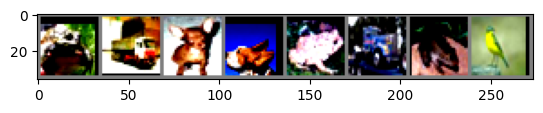

frog  truck dog   dog   frog  truck frog  bird 


In [20]:
def imshow(img):
    img = img / 2 + 0.5     # 反归一化 (简化处理)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# 获取一些随机训练图像
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 显示图像
imshow(torchvision.utils.make_grid(images[:8]))
# 打印标签
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))


## 4. 构建 VGG-11 模型

我们将手动实现 VGG-11。VGG-11 的配置通常表示为 `[64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']`。
其中数字代表卷积层通道数，'M' 代表最大池化层。
为了提高模型性能，我们加入了 **Batch Normalization (批归一化)** 层。


In [21]:
class VGG11(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG11, self).__init__()
        self.features = self._make_layers([64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'])
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        out = self.features(x)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                           nn.BatchNorm2d(x),
                           nn.ReLU(inplace=True)]
                in_channels = x
        return nn.Sequential(*layers)

model = VGG11().to(device)
print(model)


VGG11(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(

## 5. 定义损失函数与优化器

对于多分类任务，我们通常使用 **交叉熵损失函数 (CrossEntropyLoss)**。
优化器选择带动量的 **SGD**，并辅以学习率衰减策略。


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# 学习率调整策略：每 20 个 epoch 缩小为原来的 0.1 倍
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)


## 6. 模型训练

我们将进行 10 轮迭代。在每一轮中，我们都会记录训练损失和准确率。
> **注意**：为了获得更好的结果，实际应用中通常需要训练 100 轮以上。


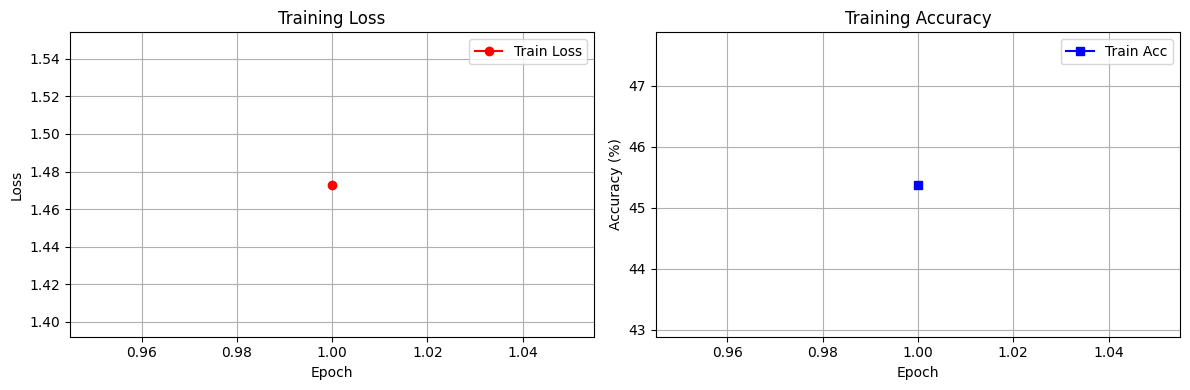

Epoch [1/1] 完成! Loss: 1.4731, Acc: 45.38%
训练全部完成！


In [ ]:
epochs = 10
train_losses = []
train_accs = []

print("开始训练...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # 使用 tqdm 打印进度条
    pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}', unit='batch')
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # 更新进度条右侧的显示信息
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{100. * correct / total:.2f}%')

    scheduler.step()
    
    # 记录本轮数据
    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    # --- 实时绘制损失和准确率曲线 ---
    clear_output(wait=True)
    plt.figure(figsize=(12, 4))
    
    # 损失曲线
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epoch + 2), train_losses, marker='o', color='red', label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    # 准确率曲线
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epoch + 2), train_accs, marker='s', color='blue', label='Train Acc')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f'Epoch [{epoch+1}/{epochs}] 完成! Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%')

print("训练全部完成！")


## 7. 测试集图像推理演示

在模型训练完成后，最直观的评估方式就是让它“看图识物”。我们将从 `test` 文件夹中随机抽取一些图片，观察模型的预测结果。

> **提示**：由于测试集没有标签，我们只能通过肉眼观察来确认模型预测是否符合常理。

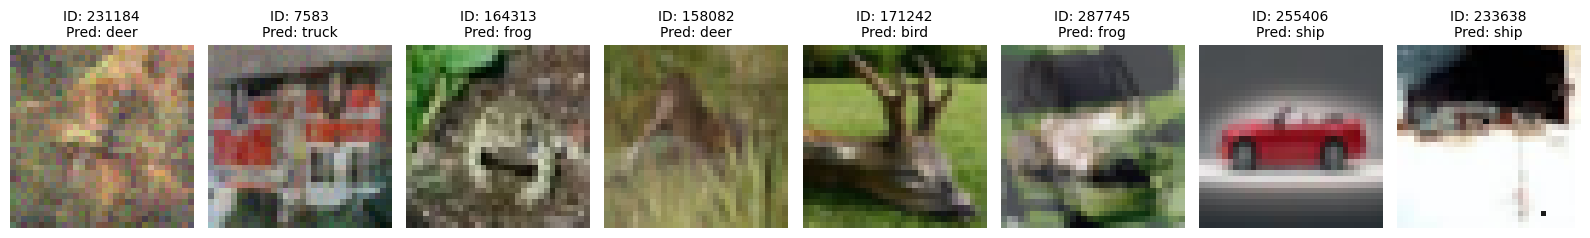

In [24]:
# --- 推理演示：从测试集中随机抽取 8 张图进行预测 ---
import random

test_dir = os.path.join(data_root, 'test')

if not os.path.exists(test_dir):
    print(f"找不到测试文件夹: {test_dir}")
else:
    # 获取测试图片列表
    all_test_files = [f for f in os.listdir(test_dir) if f.lower().endswith('.png')]
    
    if len(all_test_files) < 8:
        print("测试图片不足 8 张。")
    else:
        # 随机抽取 8 张
        sample_files = random.sample(all_test_files, 8)
        
        model.eval()
        plt.figure(figsize=(16, 4))
        
        for i, filename in enumerate(sample_files):
            img_path = os.path.join(test_dir, filename)
            image = Image.open(img_path).convert('RGB')
            
            # 预处理
            input_tensor = transform_test(image).unsqueeze(0).to(device)
            
            # 推理
            with torch.no_grad():
                output = model(input_tensor)
                _, predicted = output.max(1)
                pred_label = classes[predicted.item()]
            
            # 可视化
            plt.subplot(1, 8, i + 1)
            plt.imshow(image)
            plt.title(f"ID: {filename.split('.')[0]}\nPred: {pred_label}", fontsize=10)
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()

## 8. 模型性能评估

虽然直观的推理很有趣，但在机器学习中，我们需要量化的指标（如准确率 Accuracy）来客观评价模型的优劣。下面我们在验证集上计算整体的分类表现。

In [25]:
# --- 性能评估：计算验证集上的总准确率 ---
model.eval()
correct = 0
total = 0

print("正在计算验证集准确率...")
with torch.no_grad():
    for inputs, labels in tqdm(valloader, desc="Evaluating", unit="batch"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

accuracy = 100 * correct / total
print(f'\n评估结果:')
print(f'验证集总样本数: {total}')
print(f'预测正确样本数: {correct}')
print(f'全局准确率 (Accuracy): {accuracy:.2f}%')

正在计算验证集准确率...


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.96batch/s]


评估结果:
验证集总样本数: 5000
预测正确样本数: 2881
全局准确率 (Accuracy): 57.62%


## 9. 拓展、思考与总结

作为教学案例，VGG-11 只是我们迈向深度学习的第一步。以下问题值得你深入思考：

###  核心思考题

| 维度 | 问题 | 解答思路 |
| :--- | :--- | :--- |
| **层归一化** | 如果去掉 `nn.BatchNorm2d` 会怎样？ | BN 层稳定了内部值分布，去掉后可能需要极小的学习率，否则容易梯度消失/爆炸，收敛变慢。 |
| **参数分析** | VGG 的参数主要集中在卷积层还是全连接层？ | 主要在第一个全连接层（FC1）。由于特征图展平后维度巨大（512x1x1 -> 4096），FC 层的权重矩阵极其庞大。 |
| **感受野** | 两个 3x3 卷积核相比一个 5x5 卷积核有何优势？ | 1. 相同的感受野；2. 参数量更少（18 vs 25）；3. 更多非线性激活，学习能力更强。 |

###  进阶挑战
*   **尝试 VGG-16**：修改 `VGG11` 类中的特征配置列表 `[64, 64, 'M', 128, 128, 'M', ...]` 即可实现。
*   **改进全连接层**：对于像 CIFAR-10 这样的小图（32x32），是否有必要使用 4096 维的全连接层？尝试调小它。